<a href="https://colab.research.google.com/github/jobellet/Dynamics-of-Visual-Representations-in-a-Macaque-Ventrolateral-Prefrontal-Cortex/blob/main/DNN_metrics_overview.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ──────────────────────────────────────────────────────────────────────
# DATA SETUP WIDGET (Universal: Colab, Kaggle & Local)
# ──────────────────────────────────────────────────────────────────────
import ipywidgets as widgets
from IPython.display import display, clear_output
import os
import shutil
from pathlib import Path

# --- 1. CONFIGURATION
REQUIRED_FILES = [
    "category_decoding_accuracy.csv",
    "position_decoding_mae.csv",
    "dnn_parameter_counts.csv",
    "network_mean_rsas_all_conditions.csv"  # <--- NEW FILE ADDED
]

DEST_DIR = Path("downloads")
DEST_DIR.mkdir(exist_ok=True)

# Detect Environment
IN_COLAB = False
try:
    if 'google.colab' in str(get_ipython()):
        IN_COLAB = True
except NameError:
    pass
IN_KAGGLE = 'KAGGLE_KERNEL_RUN_TYPE' in os.environ

# --- UI Elements ---
style = {'description_width': '120px'}
layout_full = widgets.Layout(width='98%')

header = widgets.HTML("<h2>📂 Data Import Manager</h2>")

options = ['Local Upload']
if IN_COLAB:
    options = ['Google Drive', 'Local Upload']
elif IN_KAGGLE:
    options = ['Kaggle Input', 'Local Upload']
else:
    options = ['Local Storage', 'Local Upload']

source_toggle = widgets.ToggleButtons(
    options=options,
    description='Select Source:',
    button_style='info',
    style=style
)

path_input = widgets.Text(
    value='/content/drive/MyDrive/vlPFC_Geometry' if IN_COLAB else '.',
    placeholder='Enter absolute path to data folder...',
    description='Data Path:',
    disabled=False,
    layout=layout_full,
    style=style
)

btn_action = widgets.Button(
    description='Start Import',
    button_style='primary',
    icon='download',
    layout=widgets.Layout(width='200px')
)

out_log = widgets.Output(layout={'border': '1px solid #ddd', 'padding': '10px'})

# --- Logic ---
def update_ui(change):
    if source_toggle.value == 'Local Upload':
        path_input.layout.display = 'none'
    else:
        path_input.layout.display = 'flex'
        if source_toggle.value == 'Google Drive':
            path_input.description = 'Drive Path:'
        elif source_toggle.value == 'Local Storage':
            path_input.description = 'Local Path:'
        elif source_toggle.value == 'Kaggle Input':
            path_input.description = 'Input Path:'
            path_input.value = '/kaggle/input/vlpfc-geometry'

source_toggle.observe(update_ui, 'value')

def on_click_action(b):
    with out_log:
        clear_output()
        mode = source_toggle.value

        if mode == 'Local Upload':
            if IN_COLAB:
                from google.colab import files
                print("🚀 Upload files now (select all required files):")
                uploaded = files.upload()
                for name in uploaded:
                    shutil.move(name, DEST_DIR / name)
                print("\n✅ Upload complete.")
            else:
                print("⚠️ Manual upload widget is Colab-only.")
                print(f"👉 Please manually copy files to: {DEST_DIR.absolute()}")
            return

        src_path = Path(path_input.value)
        if mode == 'Google Drive' and not src_path.exists():
            from google.colab import drive
            print("🔄 Mounting Google Drive...")
            drive.mount('/content/drive')

        if not src_path.exists():
            print(f"❌ Error: Path not found: {src_path}")
            return

        print(f"🔎 Scanning {src_path} for files...")
        for fname in REQUIRED_FILES:
            dest = DEST_DIR / fname
            if dest.exists():
                print(f"   • {fname}: Already exists (Skipping)")
                continue

            found = list(src_path.rglob(fname))
            if found:
                print(f"   • Copying {fname}...", end=" ")
                shutil.copy(found[0], dest)
                print("Done.")
            else:
                print(f"   ❌ {fname}: Not found in source path.")

        missing = [f for f in REQUIRED_FILES if not (DEST_DIR / f).exists()]
        if not missing:
            print("\n🎉 Success! All files are in 'downloads/'. Run the next cell.")
        else:
            print(f"\n⚠️ Missing files: {missing}")

update_ui(None)
btn_action.on_click(on_click_action)
display(header, source_toggle, path_input, btn_action, out_log)

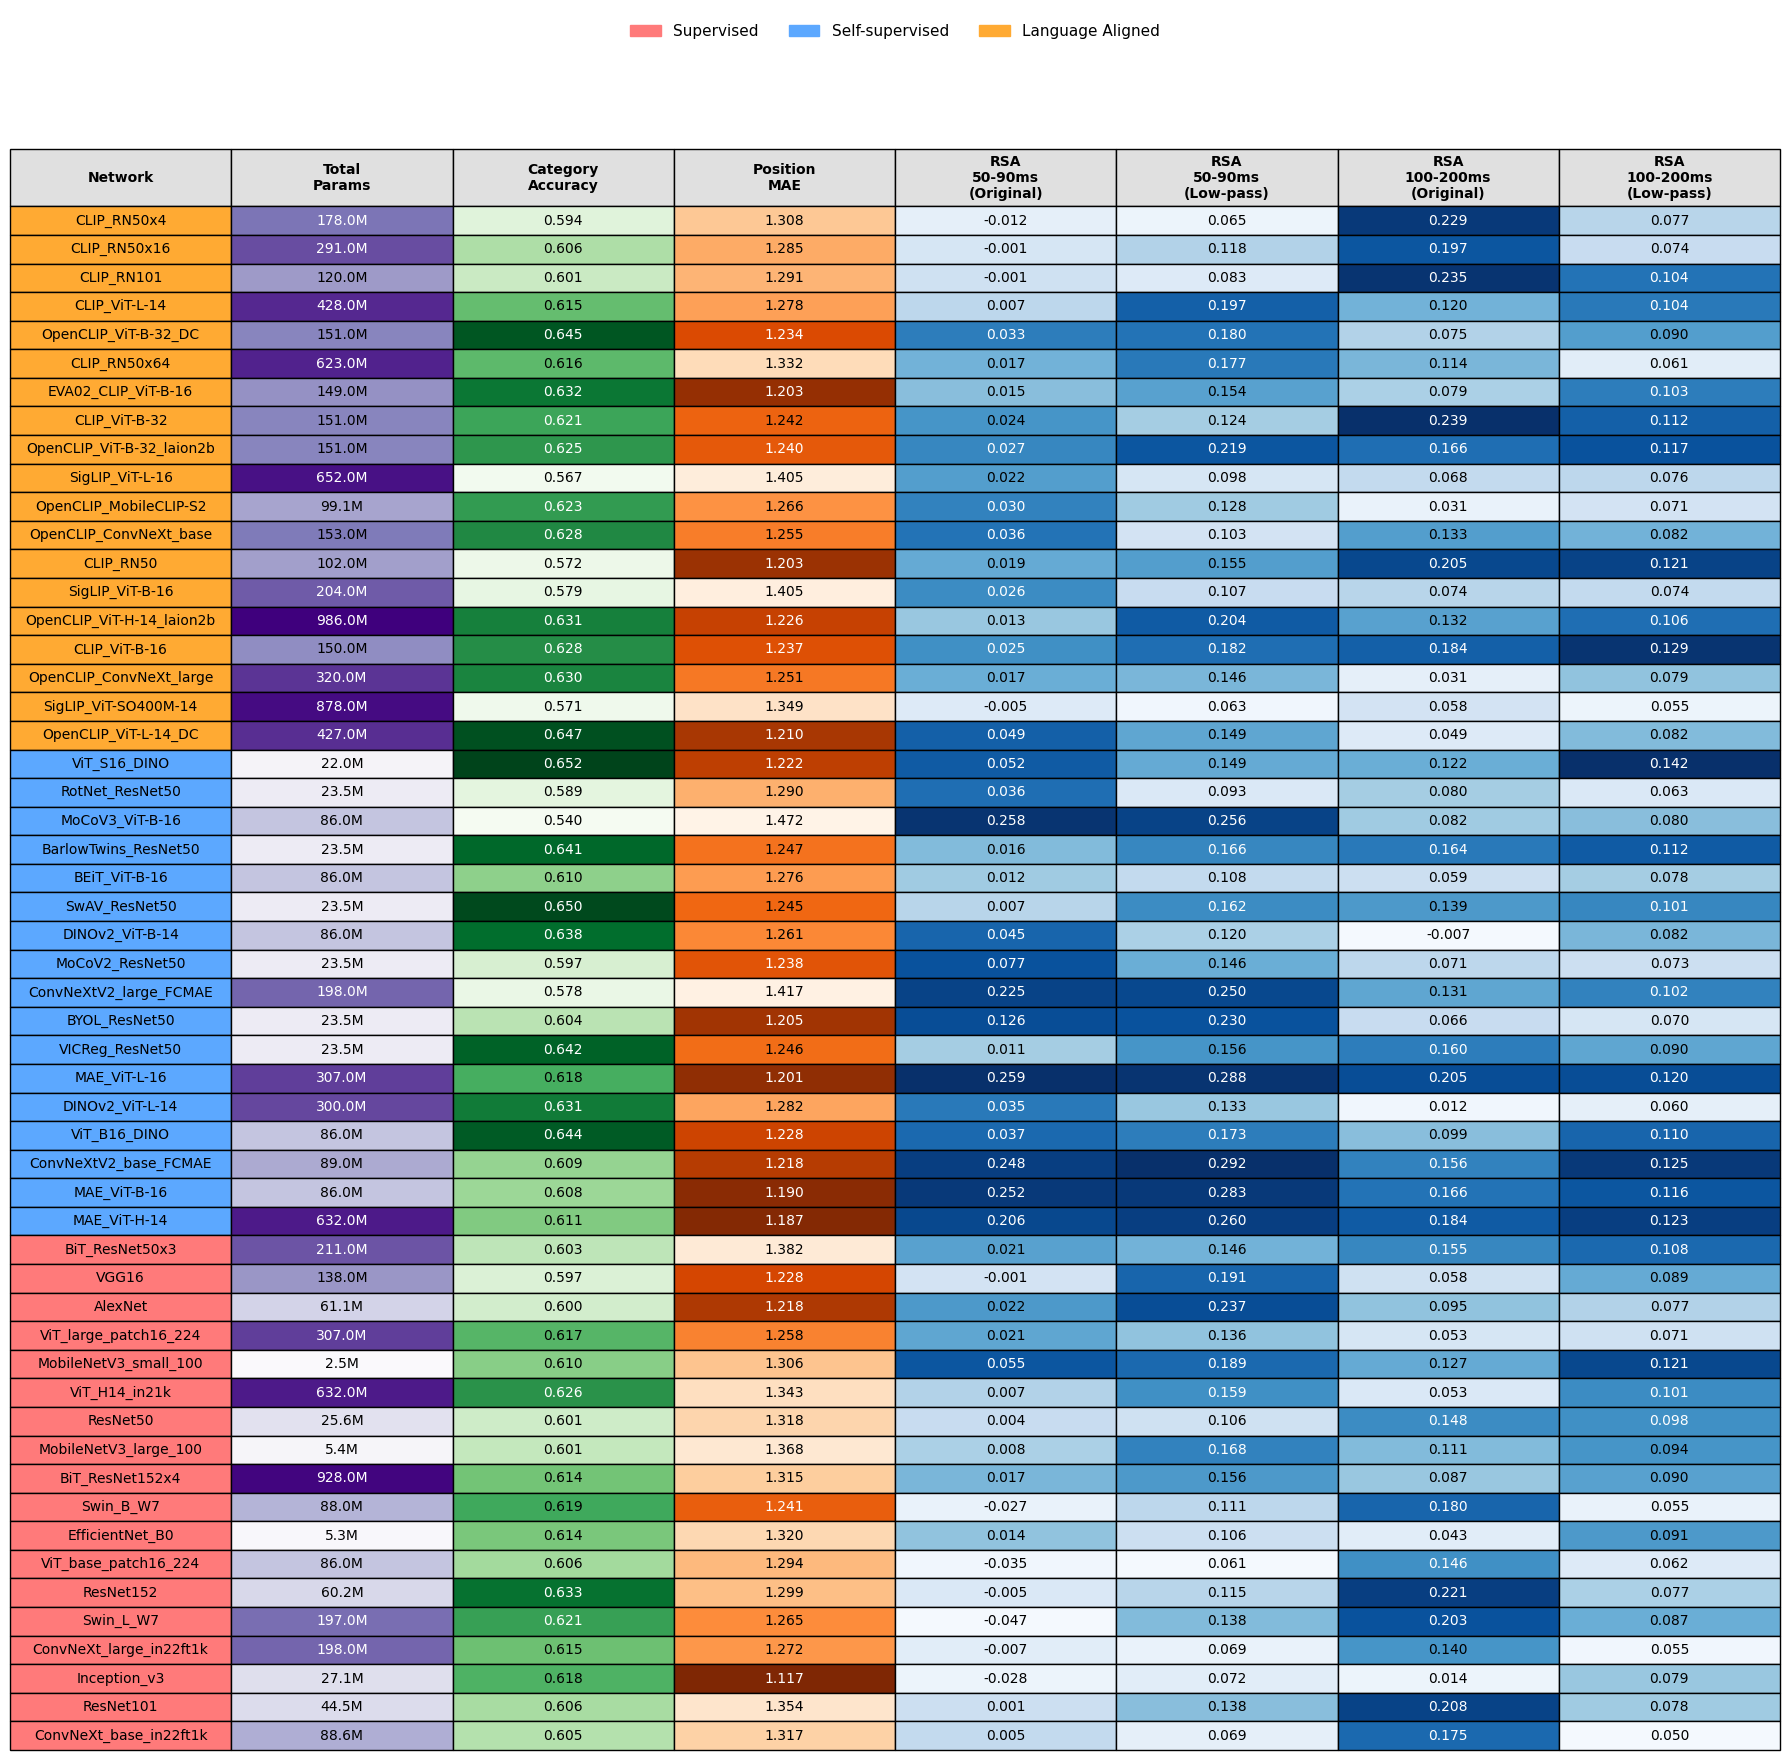

✅ Saved multi-gradient metrics table to 'metrics_table_multi_heatmap.pdf'


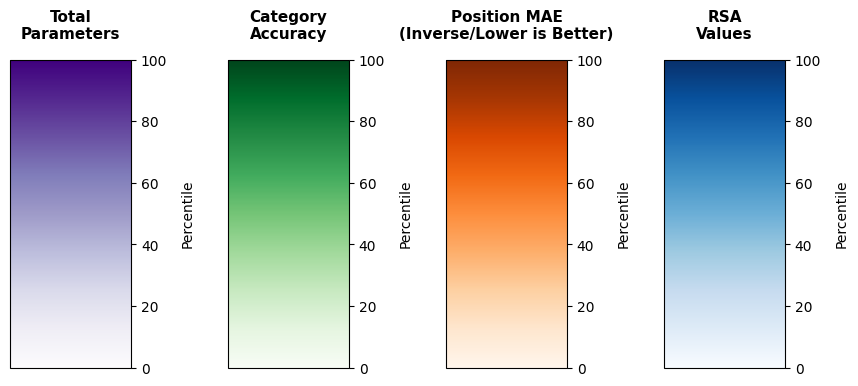

✅ Saved colorbar legends to 'colorbar_legends.pdf'


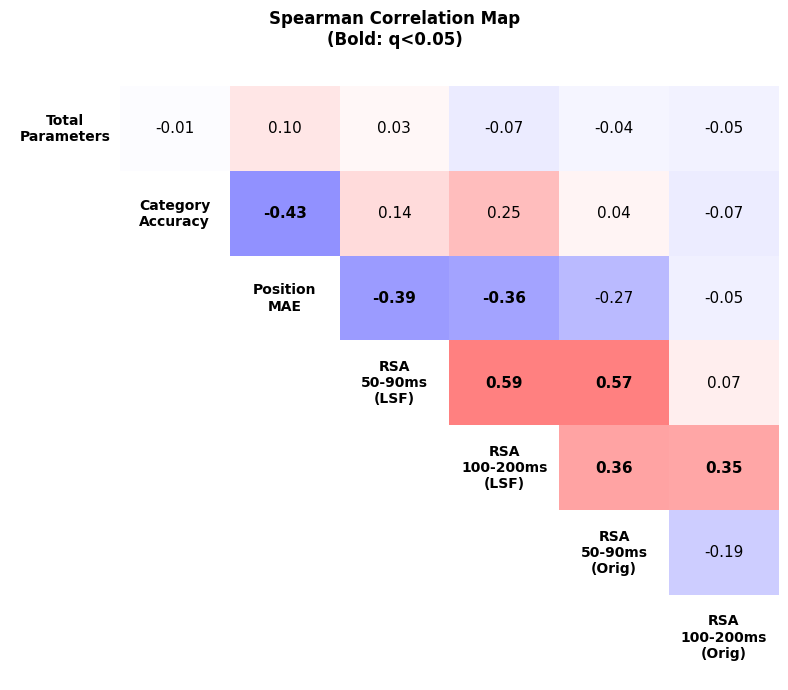

✅ Saved correlation map to 'correlation_map.pdf'


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
from scipy.stats import rankdata, spearmanr
import statsmodels.stats.multitest as smt
import matplotlib.patches as mpatches
import re

# ──────────────────────────────────────────────────────────────────────
# 1. LOAD AND ALIGN DATA
# ──────────────────────────────────────────────────────────────────────
df_cat = pd.read_csv("downloads/category_decoding_accuracy.csv")
df_pos = pd.read_csv("downloads/position_decoding_mae.csv")
df_dnn = pd.read_csv("downloads/dnn_parameter_counts.csv")
df_rsa = pd.read_csv("downloads/network_mean_rsas_all_conditions.csv")

def normalize_name(name):
    return re.sub(r'[^A-Za-z0-9]', '', str(name)).lower()

df_cat['norm_name'] = df_cat['network'].apply(normalize_name)
df_pos['norm_name'] = df_pos['network'].apply(normalize_name)
df_dnn['norm_name'] = df_dnn['Model Nickname'].apply(normalize_name)
df_rsa['norm_name'] = df_rsa['Network'].apply(normalize_name)

df_merged = df_cat.merge(df_pos, on='norm_name', suffixes=('_cat', '_pos'))
df_merged = df_merged.merge(df_dnn, on='norm_name')
df_merged = df_merged.merge(df_rsa, on='norm_name')

df_merged.sort_values(by='Training Type', inplace=True)
df_merged.reset_index(drop=True, inplace=True)

# ──────────────────────────────────────────────────────────────────────
# 2. CALCULATE PERCENTILES FOR HEATMAP COLORS
# ──────────────────────────────────────────────────────────────────────
cat_pct = rankdata(df_merged['category_accuracy']) / len(df_merged)
rsa1_pct = rankdata(df_merged['Mean RSA (50–90 ms, Original)']) / len(df_merged)
rsa2_pct = rankdata(df_merged['Mean RSA (50–90 ms, Low-pass)']) / len(df_merged)
rsa3_pct = rankdata(df_merged['Mean RSA (100–200 ms, Original)']) / len(df_merged)
rsa4_pct = rankdata(df_merged['Mean RSA (100–200 ms, Low-pass)']) / len(df_merged)
param_pct = rankdata(df_merged['Total Parameters']) / len(df_merged)

# Lower Position MAE is better -> rank inversely
pos_pct = rankdata(-df_merged['position_mae']) / len(df_merged)

# Colormaps
cmap_param = plt.get_cmap('Purples')
cmap_cat   = plt.get_cmap('Greens')
cmap_pos   = plt.get_cmap('Oranges')
cmap_rsa   = plt.get_cmap('Blues')

# Updated category colors
training_colors = {
    'Supervised': '#FF7A7A',        # Saturated Red/Coral
    'Self-supervised': '#5CA8FF',   # Saturated Sky Blue
    'Language Aligned': '#FFAA33'   # Saturated Yellow-Orange
}

columns = [
    'Network', 'Total\nParams', 'Category\nAccuracy', 'Position\nMAE',
    'RSA\n50-90ms\n(Original)', 'RSA\n50-90ms\n(Low-pass)',
    'RSA\n100-200ms\n(Original)', 'RSA\n100-200ms\n(Low-pass)'
]

# ──────────────────────────────────────────────────────────────────────
# 3. FIGURE 1: MULTI-COLOR GRADIENT TABLE
# ──────────────────────────────────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(18, len(df_merged) * 0.3 + 1.5))
ax1.set_axis_off()

cell_text = []
cell_colors_multi = []

for i in range(len(df_merged)):
    params_m = df_merged['Total Parameters'].values[i] / 1e6
    param_str = f"{params_m:.1f}M" if params_m < 1000 else f"{params_m/1000:.2f}B"
    t_type = df_merged['Training Type'].values[i]

    row_text = [
        df_merged['Network'].values[i],
        param_str,
        f"{df_merged['category_accuracy'].values[i]:.3f}",
        f"{df_merged['position_mae'].values[i]:.3f}",
        f"{df_merged['Mean RSA (50–90 ms, Original)'].values[i]:.3f}",
        f"{df_merged['Mean RSA (50–90 ms, Low-pass)'].values[i]:.3f}",
        f"{df_merged['Mean RSA (100–200 ms, Original)'].values[i]:.3f}",
        f"{df_merged['Mean RSA (100–200 ms, Low-pass)'].values[i]:.3f}"
    ]
    cell_text.append(row_text)

    row_colors = [
        training_colors.get(t_type, 'white'),
        colors.to_hex(cmap_param(param_pct[i])),
        colors.to_hex(cmap_cat(cat_pct[i])),
        colors.to_hex(cmap_pos(pos_pct[i])),
        colors.to_hex(cmap_rsa(rsa1_pct[i])),
        colors.to_hex(cmap_rsa(rsa2_pct[i])),
        colors.to_hex(cmap_rsa(rsa3_pct[i])),
        colors.to_hex(cmap_rsa(rsa4_pct[i]))
    ]
    cell_colors_multi.append(row_colors)

table1 = ax1.table(cellText=cell_text, cellColours=cell_colors_multi, colLabels=columns,
                   cellLoc='center', bbox=[0, 0, 1, 0.92])
table1.auto_set_font_size(False)
table1.set_fontsize(10)

for (row, col), cell in table1.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold')
        cell.set_facecolor('#E0E0E0')
        cell.set_height(cell.get_height() * 2)
    else:
        if col >= 1:
            bg_color = cell.get_facecolor()
            luminance = 0.299 * bg_color[0] + 0.587 * bg_color[1] + 0.114 * bg_color[2]
            if luminance < 0.5:
                cell.set_text_props(color='white')

legend_patches = [mpatches.Patch(color=color, label=label) for label, color in training_colors.items()]
ax1.legend(handles=legend_patches, loc='upper center', bbox_to_anchor=(0.5, 1.0), ncol=3, fontsize=11, frameon=False)

plt.tight_layout()
plt.savefig('metrics_table_multi_heatmap.pdf', format='pdf', bbox_inches='tight')
plt.show()
print("✅ Saved multi-gradient metrics table to 'metrics_table_multi_heatmap.pdf'")

# ──────────────────────────────────────────────────────────────────────
# 4. FIGURE 2: COLORBAR LEGENDS FOR PERCENTILES
# ──────────────────────────────────────────────────────────────────────
fig2, axes2 = plt.subplots(nrows=1, ncols=4, figsize=(10, 4))
plt.subplots_adjust(wspace=0.8)  # Add space between colorbars

metric_cmaps = [
    ('Total\nParameters', cmap_param),
    ('Category\nAccuracy', cmap_cat),
    ('Position MAE\n(Inverse/Lower is Better)', cmap_pos),
    ('RSA\nValues', cmap_rsa)
]

norm = colors.Normalize(vmin=0, vmax=100)

for ax, (label, cmap) in zip(axes2, metric_cmaps):
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig2.colorbar(sm, cax=ax, orientation='vertical')
    cbar.set_label('Percentile', rotation=90, labelpad=10)
    ax.set_title(label, fontsize=11, pad=15, fontweight='bold')

plt.savefig('colorbar_legends.pdf', format='pdf', bbox_inches='tight')
plt.show()
print("✅ Saved colorbar legends to 'colorbar_legends.pdf'")


# ──────────────────────────────────────────────────────────────────────
# 5. FIGURE 3: UPPER-DIAGONAL CORRELATION MAP
# ──────────────────────────────────────────────────────────────────────
metrics_to_correlate = {
    'Total\nParameters': 'Total Parameters',
    'Category\nAccuracy': 'category_accuracy',
    'Position\nMAE': 'position_mae',
    'RSA\n50-90ms\n(LSF)': 'Mean RSA (50–90 ms, Low-pass)',
    'RSA\n100-200ms\n(LSF)': 'Mean RSA (100–200 ms, Low-pass)',
    'RSA\n50-90ms\n(Orig)': 'Mean RSA (50–90 ms, Original)',
    'RSA\n100-200ms\n(Orig)': 'Mean RSA (100–200 ms, Original)',
}
metric_names = list(metrics_to_correlate.keys())
n_metrics = len(metric_names)

R_mat = np.zeros((n_metrics, n_metrics))
P_mat = np.zeros((n_metrics, n_metrics))

for i in range(n_metrics):
    for j in range(n_metrics):
        col1 = metrics_to_correlate[metric_names[i]]
        col2 = metrics_to_correlate[metric_names[j]]
        rho, p_val = spearmanr(df_merged[col1], df_merged[col2])
        R_mat[i, j] = rho
        P_mat[i, j] = p_val

flat_p = P_mat.flatten()
_, q_values = smt.fdrcorrection(flat_p, alpha=0.05, method='indep')
Q_mat = q_values.reshape((n_metrics, n_metrics))

mask_upper = np.triu(np.ones_like(R_mat, dtype=bool), k=1)
R_mat_upper = np.where(mask_upper, R_mat, np.nan)

fig3, ax3 = plt.subplots(figsize=(8, 7))

cax = ax3.imshow(R_mat_upper, cmap='bwr', vmin=-.5, vmax=.5, aspect='auto', alpha=0.5)

ax3.set_xticks([])
ax3.set_yticks([])
for spine in ax3.spines.values():
    spine.set_visible(False)

for idx in range(n_metrics):
    ax3.text(idx, idx, metric_names[idx],
             ha="center", va="center", fontsize=10, fontweight='bold')

for i in range(n_metrics):
    for j in range(n_metrics):
        if j <= i:
            continue

        r_val = R_mat[i, j]
        q_val = Q_mat[i, j]

        is_sig = q_val < 0.05
        weight = 'bold' if is_sig else 'normal'

        ax3.text(j, i, f"{r_val:.2f}",
                 ha="center", va="center", color='black',
                 fontweight=weight, fontsize=11)

ax3.set_title("Spearman Correlation Map\n(Bold: q<0.05)", pad=30, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_map.pdf', format='pdf', bbox_inches='tight')
plt.show()
print("✅ Saved correlation map to 'correlation_map.pdf'")